In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

model_data = pd.read_csv(
    "../data/processed/model_data.csv",
    parse_dates=["timestamp"]
)

print("Shape:", model_data.shape)
print("Start:", model_data["timestamp"].min())
print("End:", model_data["timestamp"].max())

model_data.head()

Shape: (30309, 19)
Start: 2023-01-08 23:00:00
End: 2026-08-31 23:00:00


,timestamp,target,hour,day_of_week,month,day_of_year,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,doy_sin,doy_cos,load_lag_24,load_lag_48,load_lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168
0,2023-01-08 23:00:00,4847.0,23,6,1,8,1,-0.258819,0.965926,-0.781831,0.62349,0.137185,0.990545,4915.0,4698.0,4288.0,4158.666667,1113.275413,4273.083333
1,2023-01-09 00:00:00,4352.0,0,0,1,9,0,0.000000,1.000000,0.000000,1.00000,0.154204,0.988039,4526.0,4278.0,3936.0,4169.000000,1115.579787,4275.083333
2,2023-01-09 01:00:00,3961.0,1,0,1,9,0,0.258819,0.965926,0.000000,1.00000,0.154204,0.988039,4157.0,3951.0,3630.0,4177.583333,1114.621633,4276.250000
3,2023-01-09 02:00:00,3883.0,2,0,1,9,0,0.500000,0.866025,0.000000,1.00000,0.154204,0.988039,4026.0,3874.0,3560.0,4183.916667,1113.252654,4277.630952
4,2023-01-09 03:00:00,3779.0,3,0,1,9,0,0.707107,0.707107,0.000000,1.00000,0.154204,0.988039,3852.0,3732.0,3469.0,4188.916667,1111.402636,4279.220238


In [3]:
# =========================
# TRAIN / VALIDATION / TEST
# =========================

model_data = model_data.sort_values("timestamp").reset_index(drop=True)

train = model_data[
    model_data["timestamp"] < "2026-01-01"
].copy()

val = model_data[
    (model_data["timestamp"] >= "2026-01-01") &
    (model_data["timestamp"] < "2026-06-01")
].copy()

test = model_data[
    model_data["timestamp"] >= "2026-06-01"
].copy()

print("Train:", train.shape)
print("Validation:", val.shape)
print("Test:", test.shape)

print("\nTrain:", train["timestamp"].min(), "->", train["timestamp"].max())
print("Validation:", val["timestamp"].min(), "->", val["timestamp"].max())
print("Test:", test["timestamp"].min(), "->", test["timestamp"].max())

Train: (24817, 19)
Validation: (3284, 19)
Test: (2208, 19)

Train: 2023-01-08 23:00:00 -> 2025-12-31 23:00:00
Validation: 2026-01-01 00:00:00 -> 2026-05-31 23:00:00
Test: 2026-06-01 00:00:00 -> 2026-08-31 23:00:00


In [4]:
# =========================
# BASELINE FORECAST
# =========================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_test = test["target"]
baseline_pred = test["load_lag_24"]

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print("Baseline MAE:", round(baseline_mae, 2), "MWh")
print("Baseline RMSE:", round(baseline_rmse, 2), "MWh")

Baseline MAE: 419.78 MWh
Baseline RMSE: 605.37 MWh


In [5]:
# =========================
# FEATURES / TARGET
# =========================

feature_cols = [
    "hour",
    "day_of_week",
    "month",
    "day_of_year",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "doy_sin",
    "doy_cos",
    "load_lag_24",
    "load_lag_48",
    "load_lag_168",
    "rolling_mean_24",
    "rolling_std_24",
    "rolling_mean_168"
]

X_train = train[feature_cols]
y_train = train["target"]

X_val = val[feature_cols]
y_val = val["target"]

X_test = test[feature_cols]
y_test = test["target"]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (24817, 17)
X_val: (3284, 17)
X_test: (2208, 17)


In [6]:
# =========================
# CELL 5 - RANDOM FOREST
# =========================

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

val_pred_rf = rf.predict(X_val)

val_mae_rf = mean_absolute_error(y_val, val_pred_rf)
val_rmse_rf = np.sqrt(mean_squared_error(y_val, val_pred_rf))

print("Random Forest Validation MAE:", round(val_mae_rf, 2))
print("Random Forest Validation RMSE:", round(val_rmse_rf, 2))

Random Forest Validation MAE: 392.8
Random Forest Validation RMSE: 613.11


In [7]:
# =========================
# CELL 6 - GRADIENT BOOSTING
# =========================

from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

hgb.fit(X_train, y_train)

val_pred_hgb = hgb.predict(X_val)

val_mae_hgb = mean_absolute_error(y_val, val_pred_hgb)
val_rmse_hgb = np.sqrt(mean_squared_error(y_val, val_pred_hgb))

print("HGB Validation MAE:", round(val_mae_hgb, 2))
print("HGB Validation RMSE:", round(val_rmse_hgb, 2))

HGB Validation MAE: 396.09
HGB Validation RMSE: 609.84


In [8]:
# =========================
# CELL 7 - MODEL COMPARISON
# =========================

results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Random Forest",
        "HistGradientBoosting"
    ],
    "MAE": [
        baseline_mae,
        val_mae_rf,
        val_mae_hgb
    ],
    "RMSE": [
        baseline_rmse,
        val_rmse_rf,
        val_rmse_hgb
    ]
})

results = results.sort_values("MAE").reset_index(drop=True)

results

,Model,MAE,RMSE
0,Random Forest,392.795984,613.113719
1,HistGradientBoosting,396.089567,609.843309
2,Baseline,419.783967,605.371380


In [9]:
# =========================
# CELL 8 - SELECT BEST MODEL
# =========================

if val_mae_rf <= val_mae_hgb:
    best_model_name = "Random Forest"
    best_model = rf
else:
    best_model_name = "HistGradientBoosting"
    best_model = hgb

print("Best model:", best_model_name)

Best model: Random Forest


In [10]:
# =========================
# CELL 9 - TRAIN ON TRAIN + VALIDATION
# =========================

train_val = pd.concat([train, val]).sort_values("timestamp")

X_train_val = train_val[feature_cols]
y_train_val = train_val["target"]

best_model.fit(X_train_val, y_train_val)

test_pred = best_model.predict(X_test)

test_mae = mean_absolute_error(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print("Final Test MAE:", round(test_mae, 2), "MWh")
print("Final Test RMSE:", round(test_rmse, 2), "MWh")

Final Test MAE: 291.85 MWh
Final Test RMSE: 429.9 MWh


In [11]:
# =========================
# CELL 9 - TRAIN ON TRAIN + VALIDATION
# =========================

train_val = pd.concat([train, val]).sort_values("timestamp")

X_train_val = train_val[feature_cols]
y_train_val = train_val["target"]

best_model.fit(X_train_val, y_train_val)

test_pred = best_model.predict(X_test)

test_mae = mean_absolute_error(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print("Final Test MAE:", round(test_mae, 2), "MWh")
print("Final Test RMSE:", round(test_rmse, 2), "MWh")

Final Test MAE: 291.85 MWh
Final Test RMSE: 429.9 MWh


In [12]:
# =========================
# CELL 10 - MAPE
# =========================

mape = np.mean(
    np.abs((y_test - test_pred) / y_test)
) * 100

print("Test MAPE:", round(mape, 2), "%")

Test MAPE: 7.46 %


In [13]:
# =========================
# CELL 11 - FORECAST DATAFRAME
# =========================

forecast = test[
    ["timestamp", "target"]
].copy()

forecast["prediction"] = test_pred
forecast["error"] = forecast["target"] - forecast["prediction"]
forecast["abs_error"] = forecast["error"].abs()

forecast.head()

,timestamp,target,prediction,error,abs_error
28101,2026-06-01 00:00:00,4451.0,4378.186134,72.813866,72.813866
28102,2026-06-01 01:00:00,4146.0,4039.860870,106.139130,106.139130
28103,2026-06-01 02:00:00,3990.0,3886.713450,103.286550,103.286550
28104,2026-06-01 03:00:00,3845.0,3897.556660,-52.556660,52.556660
28105,2026-06-01 04:00:00,3810.0,3838.875683,-28.875683,28.875683


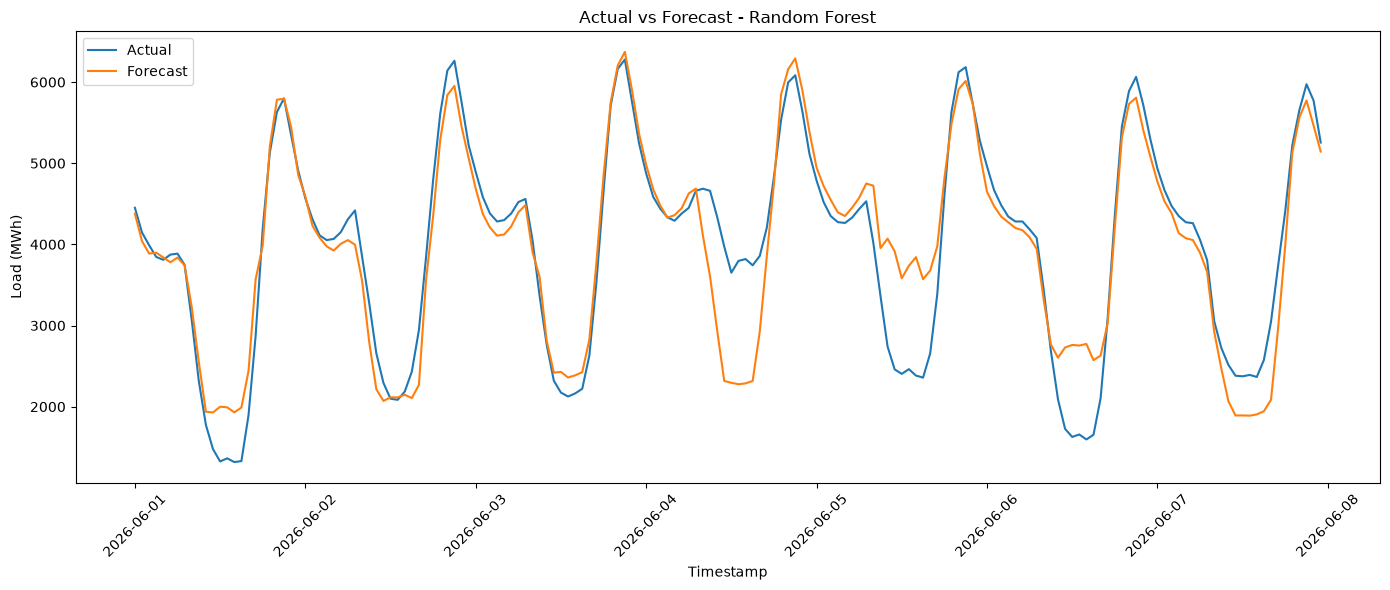

In [14]:
# =========================
# CELL 12 - ACTUAL VS FORECAST
# First 7 days
# =========================

plot_data = forecast.head(168)

plt.figure(figsize=(14, 6))

plt.plot(
    plot_data["timestamp"],
    plot_data["target"],
    label="Actual"
)

plt.plot(
    plot_data["timestamp"],
    plot_data["prediction"],
    label="Forecast"
)

plt.xlabel("Timestamp")
plt.ylabel("Load (MWh)")
plt.title(f"Actual vs Forecast - {best_model_name}")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

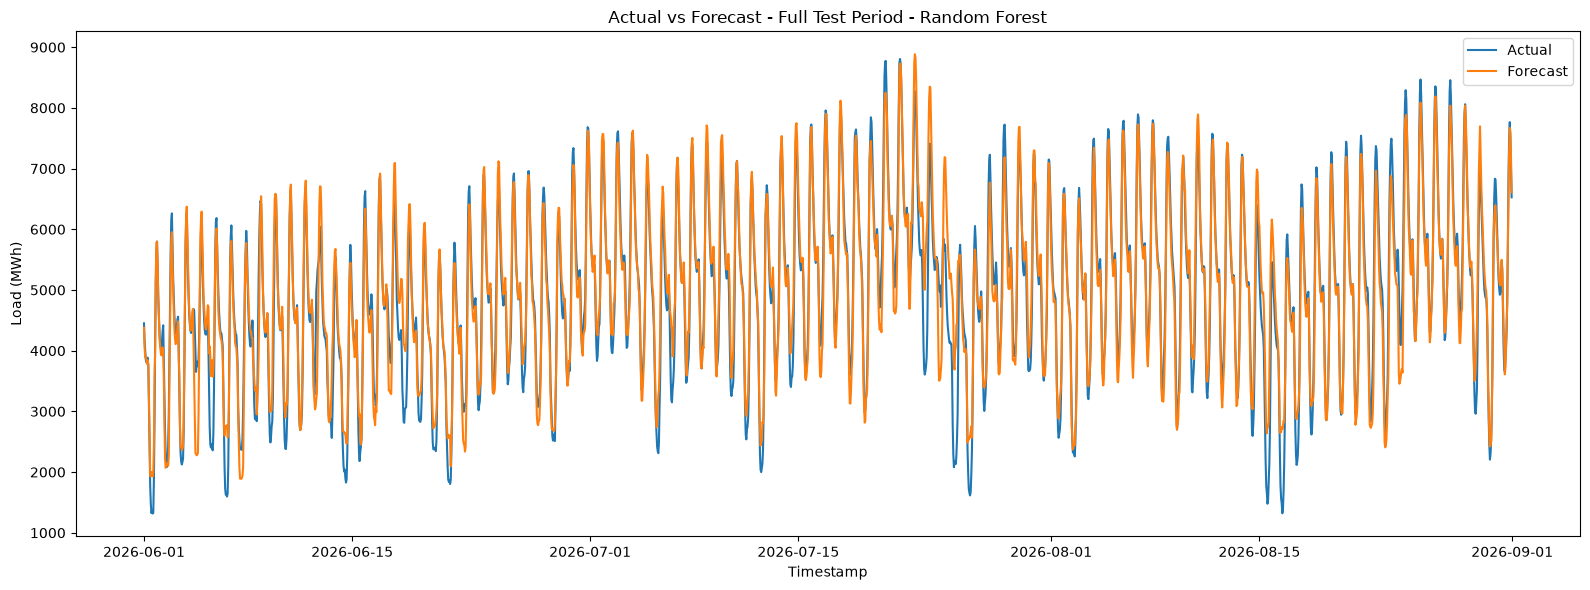

In [15]:
# =========================
# CELL 13 - FULL TEST PERIOD
# =========================

plt.figure(figsize=(16, 6))

plt.plot(
    forecast["timestamp"],
    forecast["target"],
    label="Actual"
)

plt.plot(
    forecast["timestamp"],
    forecast["prediction"],
    label="Forecast"
)

plt.xlabel("Timestamp")
plt.ylabel("Load (MWh)")
plt.title(f"Actual vs Forecast - Full Test Period - {best_model_name}")
plt.legend()
plt.tight_layout()

plt.show()

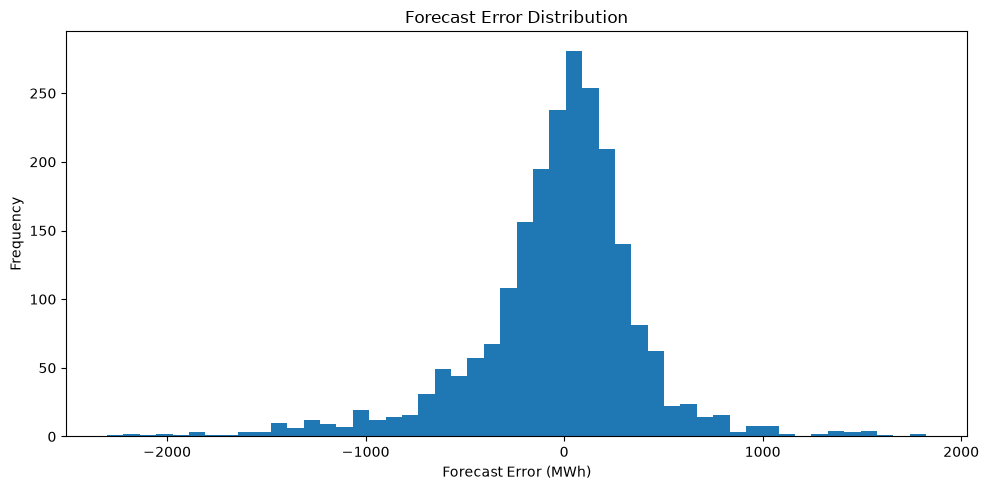

In [16]:
# =========================
# CELL 14 - ERROR DISTRIBUTION
# =========================

plt.figure(figsize=(10, 5))

plt.hist(
    forecast["error"],
    bins=50
)

plt.xlabel("Forecast Error (MWh)")
plt.ylabel("Frequency")
plt.title("Forecast Error Distribution")
plt.tight_layout()

plt.show()

In [17]:
# =========================
# CELL 15 - FEATURE IMPORTANCE
# Random Forest only
# =========================

if best_model_name == "Random Forest":

    importance = pd.DataFrame({
        "feature": feature_cols,
        "importance": best_model.feature_importances_
    }).sort_values(
        "importance",
        ascending=False
    )

    importance

In [18]:
# =========================
# CELL 15 - FEATURE IMPORTANCE
# Random Forest only
# =========================

if best_model_name == "Random Forest":

    importance = pd.DataFrame({
        "feature": feature_cols,
        "importance": best_model.feature_importances_
    }).sort_values(
        "importance",
        ascending=False
    )

    importance

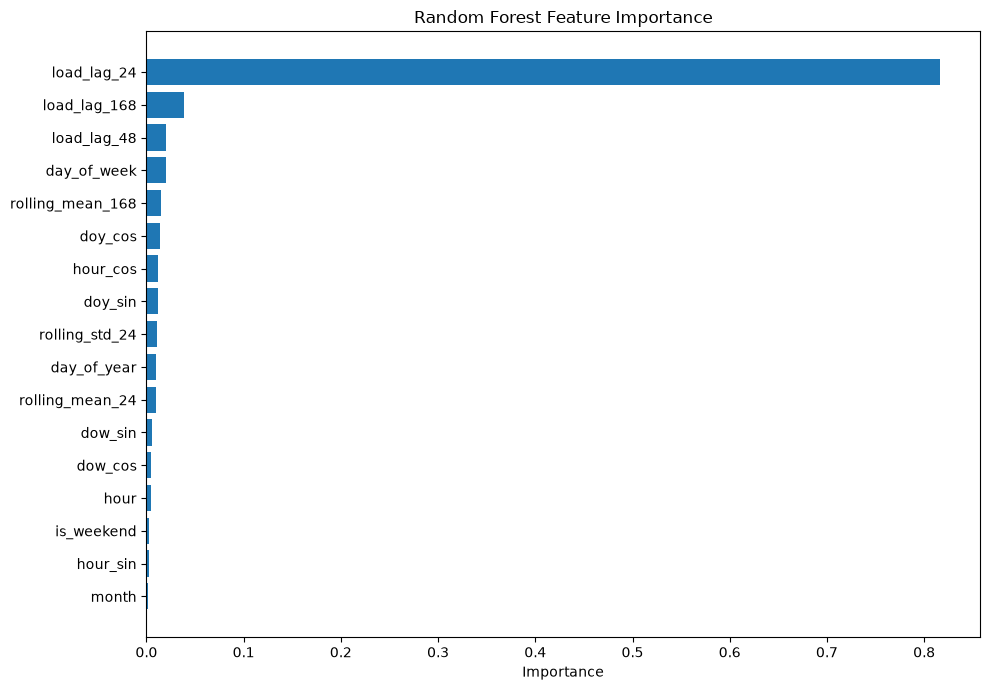

In [19]:
# =========================
# CELL 16 - FEATURE IMPORTANCE PLOT
# =========================

if best_model_name == "Random Forest":

    plt.figure(figsize=(10, 7))

    plt.barh(
        importance["feature"][::-1],
        importance["importance"][::-1]
    )

    plt.xlabel("Importance")
    plt.title("Random Forest Feature Importance")
    plt.tight_layout()

    plt.show()

In [20]:
# =========================
# CELL 17 - SAVE FORECASTS
# =========================

from pathlib import Path

Path("../data/forecasts").mkdir(
    parents=True,
    exist_ok=True
)

forecast.to_csv(
    "../data/forecasts/load_forecast_test.csv",
    index=False
)

print("Forecast saved.")

Forecast saved.


In [21]:
# =========================
# CELL 18 - FINAL SUMMARY
# =========================

print("Best Model:", best_model_name)

print("\nBaseline")
print("MAE:", round(baseline_mae, 2))
print("RMSE:", round(baseline_rmse, 2))

print("\nFinal Model")
print("MAE:", round(test_mae, 2))
print("RMSE:", round(test_rmse, 2))
print("MAPE:", round(mape, 2), "%")

improvement = (
    (baseline_mae - test_mae)
    / baseline_mae
) * 100

print(
    "\nMAE improvement over baseline:",
    round(improvement, 2),
    "%"
)

Best Model: Random Forest

Baseline
MAE: 419.78
RMSE: 605.37

Final Model
MAE: 291.85
RMSE: 429.9
MAPE: 7.46 %

MAE improvement over baseline: 30.48 %


In [22]:
# =========================
# - DAY-AHEAD FEATURES
# =========================

day_ahead_features = [
    "hour",
    "day_of_week",
    "month",
    "day_of_year",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "doy_sin",
    "doy_cos",
    "load_lag_24",
    "load_lag_48",
    "load_lag_168"
]

print("Number of features:", len(day_ahead_features))

Number of features: 14


In [23]:
# =========================
# DAY-AHEAD MODEL EVALUATION
# =========================

X_train_val_da = train_val[day_ahead_features]
y_train_val_da = train_val["target"]

X_test_da = test[day_ahead_features]
y_test_da = test["target"]

rf_day_ahead = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_day_ahead.fit(X_train_val_da, y_train_val_da)

test_pred_da = rf_day_ahead.predict(X_test_da)

da_mae = mean_absolute_error(y_test_da, test_pred_da)
da_rmse = np.sqrt(mean_squared_error(y_test_da, test_pred_da))
da_mape = np.mean(
    np.abs((y_test_da - test_pred_da) / y_test_da)
) * 100

print("Day-ahead Test MAE:", round(da_mae, 2), "MWh")
print("Day-ahead Test RMSE:", round(da_rmse, 2), "MWh")
print("Day-ahead Test MAPE:", round(da_mape, 2), "%")

Day-ahead Test MAE: 297.48 MWh
Day-ahead Test RMSE: 432.52 MWh
Day-ahead Test MAPE: 7.45 %


In [24]:
# =========================
# CELL 22 - DAY-AHEAD MODEL EVALUATION
# =========================

X_train_val_da = train_val[day_ahead_features]
y_train_val_da = train_val["target"]

X_test_da = test[day_ahead_features]
y_test_da = test["target"]

rf_day_ahead = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_day_ahead.fit(X_train_val_da, y_train_val_da)

test_pred_da = rf_day_ahead.predict(X_test_da)

da_mae = mean_absolute_error(y_test_da, test_pred_da)
da_rmse = np.sqrt(mean_squared_error(y_test_da, test_pred_da))
da_mape = np.mean(
    np.abs((y_test_da - test_pred_da) / y_test_da)
) * 100

print("Day-ahead Test MAE:", round(da_mae, 2), "MWh")
print("Day-ahead Test RMSE:", round(da_rmse, 2), "MWh")
print("Day-ahead Test MAPE:", round(da_mape, 2), "%")

Day-ahead Test MAE: 297.48 MWh
Day-ahead Test RMSE: 432.52 MWh
Day-ahead Test MAPE: 7.45 %


In [25]:
# =========================
# CELL 23 - FINAL DAY-AHEAD MODEL
# =========================

X_all = model_data[day_ahead_features]
y_all = model_data["target"]

rf_day_ahead.fit(X_all, y_all)

print("Final model trained on:", len(X_all), "rows")
print(
    "Training data until:",
    model_data["timestamp"].max()
)

Final model trained on: 30309 rows
Training data until: 2026-08-31 23:00:00


In [26]:
# =========================
# CELL 24 - FUTURE TIMESTAMPS
# =========================

forecast_start = (
    model_data["timestamp"].max()
    + pd.Timedelta(hours=1)
)

future_timestamps = pd.date_range(
    start=forecast_start,
    periods=24,
    freq="h"
)

future = pd.DataFrame({
    "timestamp": future_timestamps
})

future

,timestamp
0,2026-09-01 00:00:00
1,2026-09-01 01:00:00
2,2026-09-01 02:00:00
3,2026-09-01 03:00:00
4,2026-09-01 04:00:00
5,2026-09-01 05:00:00
6,2026-09-01 06:00:00
7,2026-09-01 07:00:00
8,2026-09-01 08:00:00
9,2026-09-01 09:00:00


In [27]:
# =========================
# CELL 25 - FUTURE CALENDAR FEATURES
# =========================

future["hour"] = future["timestamp"].dt.hour
future["day_of_week"] = future["timestamp"].dt.dayofweek
future["month"] = future["timestamp"].dt.month
future["day_of_year"] = future["timestamp"].dt.dayofyear

future["is_weekend"] = (
    future["day_of_week"] >= 5
).astype(int)

future["hour_sin"] = np.sin(
    2 * np.pi * future["hour"] / 24
)

future["hour_cos"] = np.cos(
    2 * np.pi * future["hour"] / 24
)

future["dow_sin"] = np.sin(
    2 * np.pi * future["day_of_week"] / 7
)

future["dow_cos"] = np.cos(
    2 * np.pi * future["day_of_week"] / 7
)

future["doy_sin"] = np.sin(
    2 * np.pi * future["day_of_year"] / 365.25
)

future["doy_cos"] = np.cos(
    2 * np.pi * future["day_of_year"] / 365.25
)

In [28]:
# =========================
# CELL 26 - FUTURE LAGS
# =========================

load_history = (
    model_data
    .set_index("timestamp")["target"]
)

future["load_lag_24"] = future["timestamp"].apply(
    lambda t: load_history.get(
        t - pd.Timedelta(hours=24),
        np.nan
    )
)

future["load_lag_48"] = future["timestamp"].apply(
    lambda t: load_history.get(
        t - pd.Timedelta(hours=48),
        np.nan
    )
)

future["load_lag_168"] = future["timestamp"].apply(
    lambda t: load_history.get(
        t - pd.Timedelta(hours=168),
        np.nan
    )
)

future[
    [
        "timestamp",
        "load_lag_24",
        "load_lag_48",
        "load_lag_168"
    ]
]

,timestamp,load_lag_24,load_lag_48,load_lag_168
0,2026-09-01 00:00:00,5846.0,5809.0,6732.0
1,2026-09-01 01:00:00,5445.0,5503.0,6293.0
2,2026-09-01 02:00:00,5182.0,5218.0,5967.0
3,2026-09-01 03:00:00,5014.0,5009.0,5730.0
4,2026-09-01 04:00:00,4921.0,4921.0,5548.0
5,2026-09-01 05:00:00,4951.0,4871.0,5496.0
6,2026-09-01 06:00:00,5250.0,4873.0,5638.0
7,2026-09-01 07:00:00,5472.0,4691.0,5835.0
8,2026-09-01 08:00:00,5291.0,4199.0,5552.0
9,2026-09-01 09:00:00,4711.0,3511.0,4982.0


In [29]:
# =========================
# CELL 27 - CHECK FEATURES
# =========================

print(
    future[day_ahead_features]
    .isna()
    .sum()
)

assert not future[
    day_ahead_features
].isna().any().any()

print("\nAll future features ready.")

hour            0
day_of_week     0
month           0
day_of_year     0
is_weekend      0
hour_sin        0
hour_cos        0
dow_sin         0
dow_cos         0
doy_sin         0
doy_cos         0
load_lag_24     0
load_lag_48     0
load_lag_168    0
dtype: int64

All future features ready.


In [30]:
# =========================
# CELL 28 - 24H FORECAST
# =========================

X_future = future[day_ahead_features]

future["forecast_mwh"] = rf_day_ahead.predict(
    X_future
)

day_ahead_forecast = future[
    ["timestamp", "forecast_mwh"]
].copy()

day_ahead_forecast

,timestamp,forecast_mwh
0,2026-09-01 00:00:00,5992.677578
1,2026-09-01 01:00:00,5611.152324
2,2026-09-01 02:00:00,5306.246624
3,2026-09-01 03:00:00,5135.884512
4,2026-09-01 04:00:00,5014.314904
5,2026-09-01 05:00:00,5093.805644
6,2026-09-01 06:00:00,5322.826993
7,2026-09-01 07:00:00,5557.724235
8,2026-09-01 08:00:00,5332.776048
9,2026-09-01 09:00:00,4821.024125


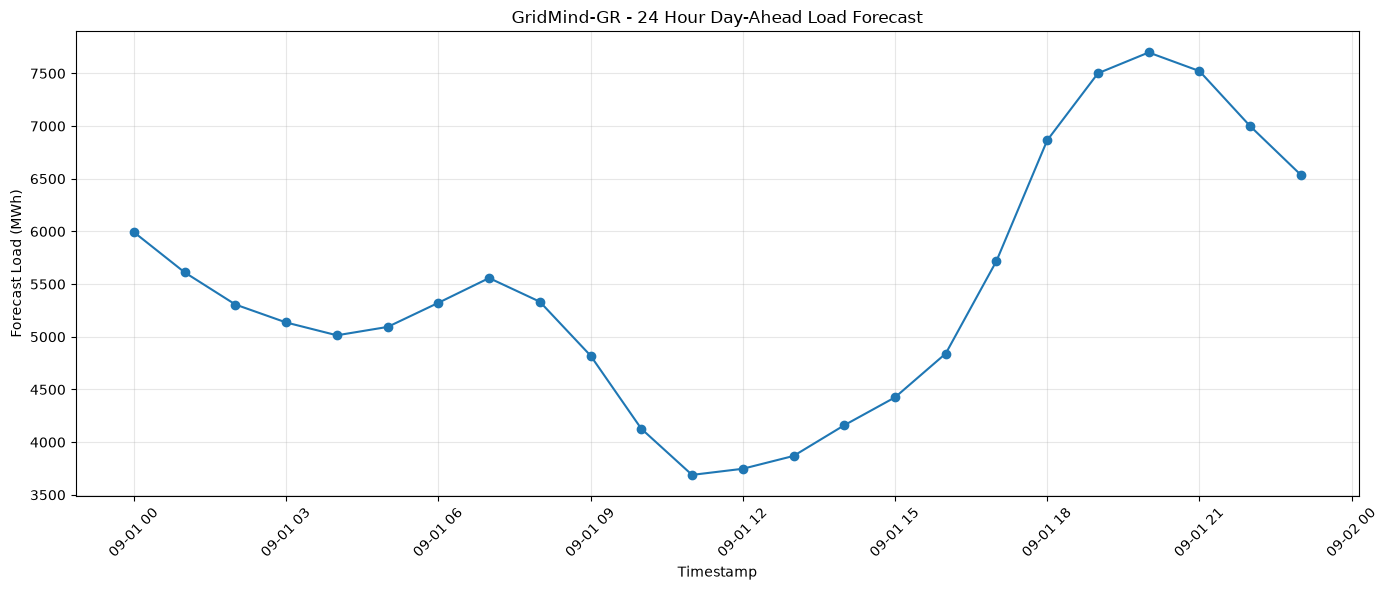

In [31]:
# =========================
# CELL 29 - FORECAST PLOT
# =========================

plt.figure(figsize=(14, 6))

plt.plot(
    day_ahead_forecast["timestamp"],
    day_ahead_forecast["forecast_mwh"],
    marker="o"
)

plt.xlabel("Timestamp")
plt.ylabel("Forecast Load (MWh)")
plt.title(
    "GridMind-GR - 24 Hour Day-Ahead Load Forecast"
)

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [32]:
# =========================
# CELL 30 - SAVE DAY-AHEAD FORECAST
# =========================

Path("../data/forecasts").mkdir(
    parents=True,
    exist_ok=True
)

day_ahead_forecast.to_csv(
    "../data/forecasts/day_ahead_forecast.csv",
    index=False
)

print("Saved day-ahead forecast.")

Saved day-ahead forecast.


In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

FEATURE_COLS = [
    "hour",
    "day_of_week",
    "is_weekend",
    "load_lag_24",
    "load_lag_48",
    "load_lag_168",
]

# Train / Test
X_train = train[FEATURE_COLS]
y_train = train["target"]

X_test = test[FEATURE_COLS]
y_test = test["target"]

# Model
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Predictions
test_predictions = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, test_predictions)
rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
mape = np.mean(np.abs((y_test - test_predictions) / y_test)) * 100

print("Features:", FEATURE_COLS)
print("Number of features:", len(FEATURE_COLS))
print(f"MAE: {mae:.2f} MWh")
print(f"RMSE: {rmse:.2f} MWh")
print(f"MAPE: {mape:.2f} %")

Features: ['hour', 'day_of_week', 'is_weekend', 'load_lag_24', 'load_lag_48', 'load_lag_168']
Number of features: 6
MAE: 316.17 MWh
RMSE: 455.53 MWh
MAPE: 7.87 %


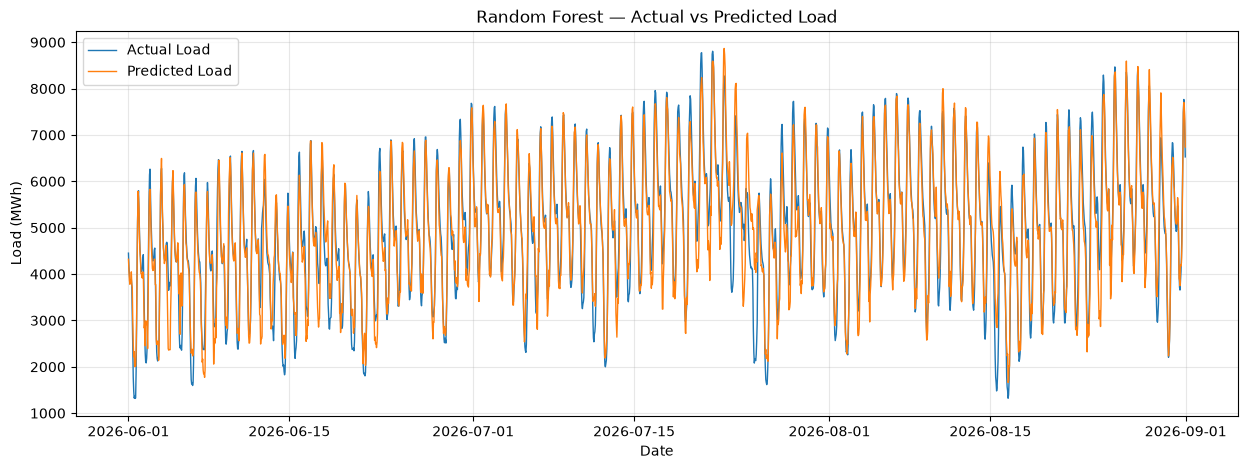

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(
    test["timestamp"],
    y_test,
    label="Actual Load",
    linewidth=1
)

plt.plot(
    test["timestamp"],
    test_predictions,
    label="Predicted Load",
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Load (MWh)")
plt.title("Random Forest — Actual vs Predicted Load")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

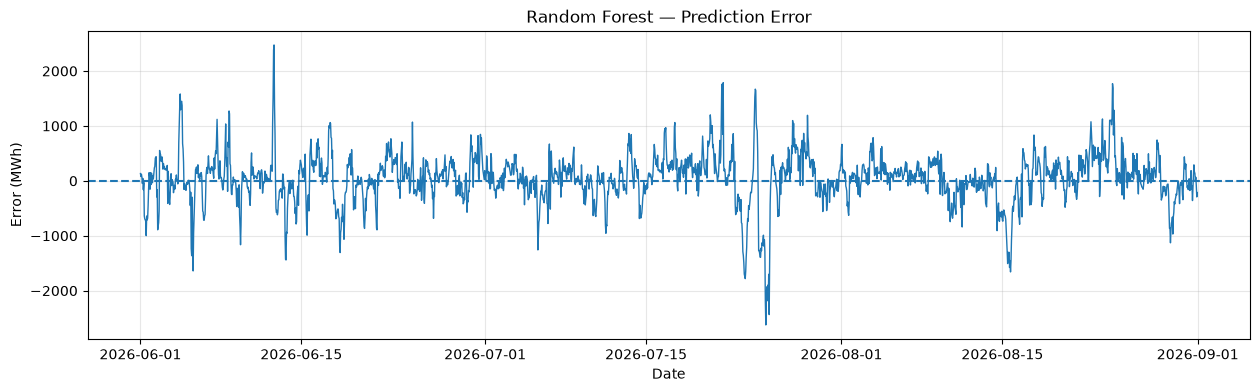

In [40]:
errors = y_test.values - test_predictions

plt.figure(figsize=(15, 4))

plt.plot(
    test["timestamp"],
    errors,
    linewidth=1
)

plt.axhline(0, linestyle="--")

plt.xlabel("Date")
plt.ylabel("Error (MWh)")
plt.title("Random Forest — Prediction Error")
plt.grid(alpha=0.3)

plt.show()

In [41]:
from sklearn.ensemble import RandomForestRegressor

FEATURE_COLS = [
    "hour",
    "day_of_week",
    "is_weekend",
    "load_lag_24",
    "load_lag_48",
    "load_lag_168",
]

X_all = model_data[FEATURE_COLS]
y_all = model_data["target"]

final_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_all, y_all)

print("Final model trained.")
print("Training rows:", len(X_all))
print("Features:", len(FEATURE_COLS))
print("Last timestamp:", model_data["timestamp"].max())

Final model trained.
Training rows: 30309
Features: 6
Last timestamp: 2026-08-31 23:00:00


In [42]:
# Next 24 hours
last_timestamp = model_data["timestamp"].max()

future_timestamps = pd.date_range(
    start=last_timestamp + pd.Timedelta(hours=1),
    periods=24,
    freq="h"
)

future = pd.DataFrame({
    "timestamp": future_timestamps
})

# Simple time features
future["hour"] = future["timestamp"].dt.hour
future["day_of_week"] = future["timestamp"].dt.dayofweek
future["is_weekend"] = (
    future["day_of_week"] >= 5
).astype(int)

future[["timestamp", "hour", "day_of_week", "is_weekend"]]

,timestamp,hour,day_of_week,is_weekend
0,2026-09-01 00:00:00,0,1,0
1,2026-09-01 01:00:00,1,1,0
2,2026-09-01 02:00:00,2,1,0
3,2026-09-01 03:00:00,3,1,0
4,2026-09-01 04:00:00,4,1,0
5,2026-09-01 05:00:00,5,1,0
6,2026-09-01 06:00:00,6,1,0
7,2026-09-01 07:00:00,7,1,0
8,2026-09-01 08:00:00,8,1,0
9,2026-09-01 09:00:00,9,1,0


In [43]:
# Create lookup: timestamp -> actual load
load_lookup = model_data.set_index("timestamp")["target"]

future["load_lag_24"] = future["timestamp"].apply(
    lambda t: load_lookup.get(t - pd.Timedelta(hours=24))
)

future["load_lag_48"] = future["timestamp"].apply(
    lambda t: load_lookup.get(t - pd.Timedelta(hours=48))
)

future["load_lag_168"] = future["timestamp"].apply(
    lambda t: load_lookup.get(t - pd.Timedelta(hours=168))
)

# Check
print(future[FEATURE_COLS].isna().sum())

future[
    ["timestamp", "load_lag_24", "load_lag_48", "load_lag_168"]
]

hour            0
day_of_week     0
is_weekend      0
load_lag_24     0
load_lag_48     0
load_lag_168    0
dtype: int64


,timestamp,load_lag_24,load_lag_48,load_lag_168
0,2026-09-01 00:00:00,5846.0,5809.0,6732.0
1,2026-09-01 01:00:00,5445.0,5503.0,6293.0
2,2026-09-01 02:00:00,5182.0,5218.0,5967.0
3,2026-09-01 03:00:00,5014.0,5009.0,5730.0
4,2026-09-01 04:00:00,4921.0,4921.0,5548.0
5,2026-09-01 05:00:00,4951.0,4871.0,5496.0
6,2026-09-01 06:00:00,5250.0,4873.0,5638.0
7,2026-09-01 07:00:00,5472.0,4691.0,5835.0
8,2026-09-01 08:00:00,5291.0,4199.0,5552.0
9,2026-09-01 09:00:00,4711.0,3511.0,4982.0


In [44]:
# Predict next 24 hours
X_future = future[FEATURE_COLS]

future_predictions = final_model.predict(X_future)

forecast = future[["timestamp"]].copy()
forecast["forecast_mwh"] = future_predictions

forecast


,timestamp,forecast_mwh
0,2026-09-01 00:00:00,6186.759923
1,2026-09-01 01:00:00,5785.423325
2,2026-09-01 02:00:00,5519.158099
3,2026-09-01 03:00:00,5220.417111
4,2026-09-01 04:00:00,5116.691942
5,2026-09-01 05:00:00,5208.188634
6,2026-09-01 06:00:00,5385.255531
7,2026-09-01 07:00:00,5493.046708
8,2026-09-01 08:00:00,5383.641959
9,2026-09-01 09:00:00,4935.414495


In [45]:

forecast_dir = Path("../data/forecasts")
forecast_dir.mkdir(parents=True, exist_ok=True)

forecast_path = forecast_dir / "day_ahead_forecast.csv"

forecast.to_csv(forecast_path, index=False)

print("Saved:", forecast_path)

Saved: ../data/forecasts/day_ahead_forecast.csv


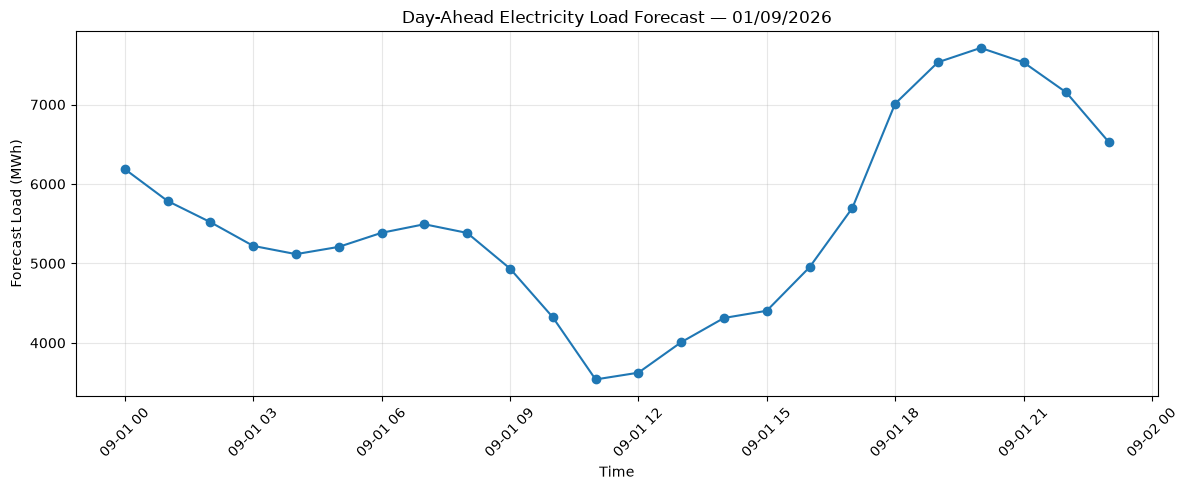

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    forecast["timestamp"],
    forecast["forecast_mwh"],
    marker="o"
)

plt.xlabel("Time")
plt.ylabel("Forecast Load (MWh)")
plt.title("Day-Ahead Electricity Load Forecast — 01/09/2026")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()